In [1]:
!pip install scanpy\
pandas\
numpy==2.0.2\
squidpy\
cell2location\
matplotlib

In [2]:
# -- Imports
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import cell2location
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel
import matplotlib.pyplot as plt
import matplotlib as mpl


import anndata as ad
ad.settings.allow_write_nullable_strings = True

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [5]:
# -- Paths
project_dir = Path(
    "/content/drive/MyDrive/endo-immune-atlas"
)

dataset = "GSE179640"


input_path_sc =(
    project_dir
    / "data"
    / "interim"
    / dataset
    / "immunosenescence.h5ad"
    )

input_path_346 = (
    project_dir
    / "data"
    / "interim"
    / "spatial"
    / "BEME_346_raw.h5ad"
    )

input_path_355G = (
    project_dir
    / "data"
    / "interim"
    / "spatial"
    / "BEME_355G_raw.h5ad"
    )

output_path_data = (
    project_dir
    / "data"
    / "interim"
    / "spatial"
    )

output_path_models = (
    project_dir
    / "models"
    / "cell2location"
    )

output_path_figures = (
    project_dir
    / "figures"
    / "spatial"
    / "cell2location"
)

output_path_data.mkdir(parents=True, exist_ok=True)
output_path_models.mkdir(parents=True, exist_ok=True)
output_path_figures.mkdir(parents=True, exist_ok=True)

In [6]:
# -- Import objects
immune_obj = sc.read_h5ad(input_path_sc)
adata_346 = sc.read_h5ad(input_path_346)
adata_355G = sc.read_h5ad(input_path_355G)

print(immune_obj)
print(adata_346)
print(adata_355G)

AnnData object with n_obs × n_vars = 27882 × 30907
    obs: 'sample_id', 'patient_id', 'tissue_type', 'condition', 'lesion_site', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribos', 'pct_counts_ribos', 'total_counts_hemos', 'pct_counts_hemos', 'n_genes', 'n_counts', 'outlier_mt', 'doublet_score', 'predicted_doublet', 'leiden_res_0.01', 'leiden_res_0.02', 'leiden_res_0.05', 'cluster_label', 'leiden_res_0.20', 'leiden_res_0.50', 'leiden_res_1.00', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'immune_cell_type', 'cell_type_short', 'lineage', 'core_sen_score', 'sasp_score', 'innate_sen_score', 'adaptive_sen_score', 'composite_sen_score', 'dysfunction_score', 'tcell_exhaustion_score', 'nk_dysfunction_score', 'macrophage_dysfunction_score', 'bcell_exhaustion_score', 'cdc1_dysfunction_score', 'cdc2_dysfunction_score', 'pdc_dysfunction_score', 'senescent_state', 'dysfunction_state', 'sen_dysfunction_label'
    var

In [7]:
#===========================================================
# FUNCTIONS
#===========================================================

def remove_mt_genes(adata):
    """Remove mitochondrial genes from a spatial object."""

    mt_mask = adata.var_names.str.startswith("MT-")

    print(
        f"Removing {mt_mask.sum()} mitochondrial genes."
    )

    return adata[:, ~mt_mask].copy()


def get_reference_signatures(reference_obj):
    """Extract estimated expression signatures from model output."""

    factor_names = reference_obj.uns["mod"]["factor_names"]

    if "means_per_cluster_mu_fg" in reference_obj.varm.keys():

        signatures = reference_obj.varm[
            "means_per_cluster_mu_fg"
        ][
            [
                f"means_per_cluster_mu_fg_{factor}"
                for factor in factor_names
            ]
        ].copy()

    else:

        signatures = reference_obj.var[
            [
                f"means_per_cluster_mu_fg_{factor}"
                for factor in factor_names
            ]
        ].copy()

    signatures.columns = factor_names

    return signatures


def add_abundance_to_obs(adata):
    """Add cell2location abundance estimates from obsm to obs."""

    abundance_key = "means_cell_abundance_w_sf"

    abundance = adata.obsm[abundance_key].copy()

    adata.obs = adata.obs.join(abundance)

    return list(abundance.columns)


def plot_spatial_abundance(
    adata,
    cell_types,
    library_id
):
    """Plot cell-type abundance and total immune abundance."""

    with mpl.rc_context(
        {
            "axes.facecolor": "black",
            "figure.figsize": [4.5, 5]
        }
    ):

        sc.pl.spatial(
            adata,
            color=cell_types,
            cmap="magma",
            ncols=4,
            size=1.3,
            img_key="hires",
            vmax="p99.2",
            show=False
        )

    plt.savefig(
        output_path_figures
        / f"07_{library_id}_immune_abundance.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    sc.pl.spatial(
        adata,
        color="Total immune",
        cmap="magma",
        img_key="hires",
        vmax="p99.2",
        show=False
    )

    plt.savefig(
        output_path_figures
        / f"07_{library_id}_total_immune.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()


def map_reference_to_spatial(
    spatial_obj,
    reference_signatures,
    library_id,
    n_cells_per_location=30,
    detection_alpha=20
):
    """Run cell2location mapping for one spatial sample."""

    spatial_obj = remove_mt_genes(spatial_obj)

    shared_genes = np.intersect1d(
        spatial_obj.var_names,
        reference_signatures.index
    )

    print(
        f"{library_id}: {len(shared_genes)} shared genes"
    )

    spatial_obj = spatial_obj[:, shared_genes].copy()
    signatures = reference_signatures.loc[shared_genes].copy()

    cell2location.models.Cell2location.setup_anndata(
        adata=spatial_obj
    )

    spatial_model = cell2location.models.Cell2location(
        spatial_obj,
        cell_state_df=signatures,
        N_cells_per_location=n_cells_per_location,
        detection_alpha=detection_alpha
    )

    spatial_model.view_anndata_setup()

    spatial_model.train(
        max_epochs=30000,
        batch_size=None,
        train_size=1,
        accelerator="gpu"
    )

    spatial_model.plot_history(1000)
    plt.legend(labels=["Full-data training"])

    plt.savefig(
        output_path_figures
        / f"07_{library_id}_training_history.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    spatial_obj = spatial_model.export_posterior(
        spatial_obj,
        sample_kwargs={
            "num_samples": 1000,
            "batch_size": spatial_model.adata.n_obs,
            "accelerator": "gpu"
        }
    )

    spatial_model.save(
        output_path_models
        / f"{library_id}_model",
        overwrite=True
    )

    posterior_file = (
        output_path_data
        / f"{library_id}_posterior.h5ad"
    )

    spatial_obj.write_h5ad(posterior_file)

    spatial_model.plot_QC()

    plt.savefig(
        output_path_figures
        / f"07_{library_id}_model_qc.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    abundance_columns = add_abundance_to_obs(spatial_obj)

    spatial_obj.obs["Total immune"] = (
        spatial_obj.obsm[
            "means_cell_abundance_w_sf"
        ][abundance_columns]
        .sum(axis=1)
    )

    plot_spatial_abundance(
        spatial_obj,
        cell_types=abundance_columns,
        library_id=library_id
    )

    output_file = (
        output_path_data
        / f"{library_id}_cell2location.h5ad"
    )

    spatial_obj.write_h5ad(output_file)

    saved_obj = sc.read_h5ad(
        output_file,
        backed="r"
    )

    print(
        f"Saved {library_id}: {saved_obj.shape}"
    )

    print(
        f"Abundance columns: {abundance_columns}"
    )

    saved_obj.file.close()

    return spatial_obj

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


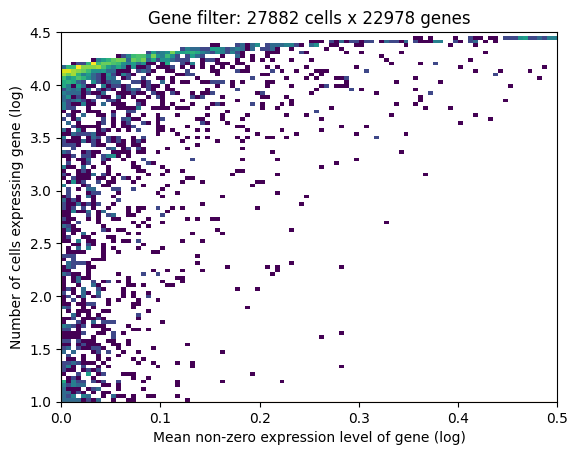

Reference genes selected: 22978
cell2location_label
γδ T        4589
NK-CD16-    4448
CD4 T       4408
TRM         3652
Mono-C      3480
NK-CD16+    2330
DC          2248
B           1319
Mono-NC      548
Treg         496
CD8 T        364
Name: count, dtype: int64


Anndata setup with scvi-tools version 1.5.0.post1.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample_id',
│   'labels_key': 'cell2location_label',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  24   │
│         n_cells          │ 27882 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  11   │
│          n_vars          │ 22978 │
└──────────────────────────┴───────┘

...

                         batch State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃     Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample_id'] │ GSM6102532_C01_Ctrl │          0          │
│                        │ GSM6102533_C02_Ctrl │          1          │
│                        │ GSM6102534_C03_Ctrl │          2          │
│                        │ GSM6102537_E01_EuE  │          3          │
│                        │ GSM6102540_E02_EuE  │          4          │
│                        │ GSM6102543_E03_EuE  │          5          │
│                        │ GSM6102546_E04_EuE  │          6          │
│                        │ GSM6102549_E05_EuE  │          7          │
│                        │ GSM6102550_E06_EcP  │          8          │
│                        │ GSM6102551_E06_EuE  │          9          │
│                        │ GSM6102552_E07_EcO  │         10          │
│                        │ GSM6102553_E07_EcP  │         11          │
│                        │ GSM6102554_E07_EuE  │         12          │
│                        │ GSM6102555_E08_EuE  │         13          │
│                        │ GSM6102556_E09_EcO  │         14          │
│                        │ GSM6102560_E09_EuE  │         15          │
│                        │ GSM6102562_E11_EcO  │         16          │
│                        │ GSM6595248_E01_EcP  │         17          │
│                        │ GSM6595250_E02_EcP  │         18          │
│                        │ GSM6595252_E03_EcP  │         19          │
│                        │ GSM6595254_E04_EcP  │         20          │
│                        │ GSM6595256_E05_EcP  │         21          │
│                        │ GSM6595258_E09_EcP  │         22          │
│                        │ GSM6595261_E10_EcO  │         23          │
└────────────────────────┴─────────────────────┴─────────────────────┘

                         labels State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃         Source Location          ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell2location_label'] │     B      │          0          │
│                                  │   CD4 T    │          1          │
│                                  │   CD8 T    │          2          │
│                                  │     DC     │          3          │
│                                  │   Mono-C   │          4          │
│                                  │  Mono-NC   │          5          │
│                                  │  NK-CD16+  │          6          │
│                                  │  NK-CD16-  │          7          │
│                                  │    TRM     │          8          │
│                                  │    Treg    │          9          │
│                                  │    γδ T    │         10          │
└──────────────────────────────────┴────────────┴─────────────────────┘

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO: You are using a CUDA device ('NVIDIA RTX PRO 60

Training:   0%|          | 0/250 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=250` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=250` reached.


In [8]:
# -- Build immune reference
selected = filter_genes(
    immune_obj,
    cell_count_cutoff=5,
    cell_percentage_cutoff2=0.05,
    nonz_mean_cutoff=0.05
)

immune_ref = immune_obj[:, selected].copy()

print(
    f"Reference genes selected: {immune_ref.n_vars}"
)


# -- Merge dendritic subtypes for spatial mapping
immune_ref.obs["cell2location_label"] = (
    immune_ref.obs["cell_type_short"]
    .astype(str)
    .replace(
        {
            "cDC1": "DC",
            "cDC2": "DC",
            "pDC": "DC"
        }
    )
)

print(
    immune_ref.obs[
        "cell2location_label"
    ].value_counts()
)


# -- Use raw counts for the regression model
if "counts" not in immune_ref.layers:
    raise KeyError(
        "The counts layer is missing from the single-cell reference."
    )

immune_ref.X = immune_ref.layers["counts"].copy()


# -- Prepare reference object
RegressionModel.setup_anndata(
    adata=immune_ref,
    batch_key="sample_id",
    labels_key="cell2location_label"
)


# -- Create regression model
reference_model = RegressionModel(immune_ref)

reference_model.view_anndata_setup()


# -- Train reference model
reference_model.train(
    max_epochs=250,
    accelerator="gpu"
)

reference_model.plot_history(20)

plt.savefig(
    output_path_figures
    / "07_reference_training_history.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [9]:
# -- Export reference posterior
immune_ref = reference_model.export_posterior(
    immune_ref,
    sample_kwargs={
        "num_samples": 1000,
        "batch_size": 2500,
        "accelerator": "gpu"
    }
)


# -- Save reference model
reference_model.save(
    output_path_models
    / "immune_reference_model",
    overwrite=True
)


# -- Save reference posterior
immune_ref.write_h5ad(
    output_path_data
    / "immune_reference_posterior.h5ad"
)

Sampling local variables, batch:   0%|          | 0/12 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

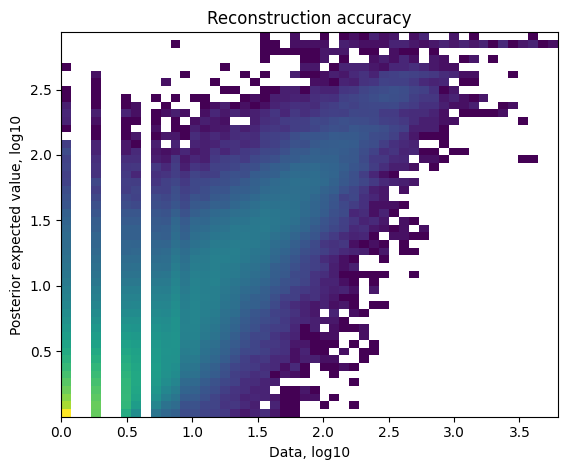

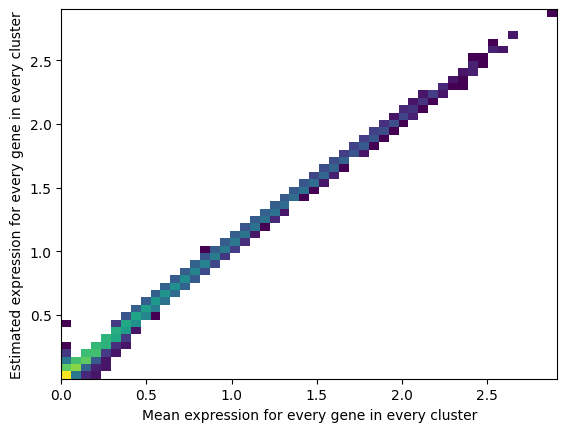

                 B     CD4 T     CD8 T        DC    Mono-C
A1BG      0.288391  0.270211  0.325185  1.162146  0.502721
A1BG-AS1  0.032326  0.023086  0.050972  0.098189  0.042183
A1CF      0.125772  0.013787  0.216496  0.094550  0.034658
A2M       0.028347  0.041340  0.046657  4.532825  0.070855
A2M-AS1   0.001197  0.125111  0.114713  0.040373  0.013394


In [10]:
# -- Reference QC
reference_model.plot_QC()

plt.savefig(
    output_path_figures
    / "07_reference_model_qc.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()


# -- Export estimated expression signatures
reference_signatures = get_reference_signatures(
    immune_ref
)

print(reference_signatures.iloc[:5, :5])

In [11]:
# ==========================================================================
# TISSUE 1: BEME_346
# ==========================================================================
adata_346 = map_reference_to_spatial(
    spatial_obj=adata_346,
    reference_signatures=reference_signatures,
    library_id="BEME_346"
)


Removing 13 mitochondrial genes.
BEME_346: 22220 shared genes


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Anndata setup with scvi-tools version 1.5.0.post1.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

...

INFO: `Trainer.fit` stopped: `max_epochs=30000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30000` reached.


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

/tmp/ipykernel_2612/2523758227.py:73: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_2612/2523758227.py:93: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Saved BEME_346: (1388, 22220)
Abundance columns: ['meanscell_abundance_w_sf_B', 'meanscell_abundance_w_sf_CD4 T', 'meanscell_abundance_w_sf_CD8 T', 'meanscell_abundance_w_sf_DC', 'meanscell_abundance_w_sf_Mono-C', 'meanscell_abundance_w_sf_Mono-NC', 'meanscell_abundance_w_sf_NK-CD16+', 'meanscell_abundance_w_sf_NK-CD16-', 'meanscell_abundance_w_sf_TRM', 'meanscell_abundance_w_sf_Treg', 'meanscell_abundance_w_sf_γδ T']


In [12]:
# ==========================================================================
# TISSUE 2: BEME_355G
# ==========================================================================

adata_355G = map_reference_to_spatial(
    spatial_obj=adata_355G,
    reference_signatures=reference_signatures,
    library_id="BEME_355G"
)



Removing 13 mitochondrial genes.
BEME_355G: 22220 shared genes


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Anndata setup with scvi-tools version 1.5.0.post1.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

...

INFO: `Trainer.fit` stopped: `max_epochs=30000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30000` reached.


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

/tmp/ipykernel_2612/2523758227.py:73: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_2612/2523758227.py:93: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Saved BEME_355G: (1960, 22220)
Abundance columns: ['meanscell_abundance_w_sf_B', 'meanscell_abundance_w_sf_CD4 T', 'meanscell_abundance_w_sf_CD8 T', 'meanscell_abundance_w_sf_DC', 'meanscell_abundance_w_sf_Mono-C', 'meanscell_abundance_w_sf_Mono-NC', 'meanscell_abundance_w_sf_NK-CD16+', 'meanscell_abundance_w_sf_NK-CD16-', 'meanscell_abundance_w_sf_TRM', 'meanscell_abundance_w_sf_Treg', 'meanscell_abundance_w_sf_γδ T']


## Notebook Summary

Completed:
- Loaded trained immune reference
- Mapped immune populations onto Visium tissue
- Estimated cell abundance per spot
- Visualized spatial distribution
- Saved annotated spatial objects

Notes:
- Cell2location could not discriminate the difference between DC subpopulations so they will be merged into 1 central group "DCs" for downstream analysis.